In [1]:
# =========================
# 0. Install XAI Libraries
# =========================
!pip install lime shap -q

print("✅ XAI libraries installed!")

✅ XAI libraries installed!


In [2]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample

# TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, BatchNormalization,
                                      GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# XAI
import shap
from lime.lime_text import LimeTextExplainer

print("✅ All imports loaded!")

✅ All imports loaded!


In [3]:
# =========================
# 2. Load & Clean Data
# =========================
data_path = "/kaggle/input/datasets/saimulhaque/disaster/different_types_of_disaster_processed.xlsx"
data = pd.read_excel(data_path)

def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", str(text))
    text = re.sub(r"@\w+|#", "", text)
    text = re.sub(r"[^A-Za-z\s]", "", text)
    return text.lower().strip()

data['clean_tweet'] = data['tweet_text'].apply(clean_text)
data = data.dropna(subset=['disaster_type'])

# Encode labels
label_enc = LabelEncoder()
data['label'] = label_enc.fit_transform(data['disaster_type'])
class_names = label_enc.classes_

print(f"Classes: {class_names}")
print(f"Total samples: {len(data)}")

Classes: ['bombing' 'cyclone' 'earthquake' 'explosion' 'fire' 'flood'
 'helicopter crash' 'hurricane' 'shooting' 'tornado' 'train crash'
 'typhoon' 'wildfire']
Total samples: 42953


In [4]:
# =========================
# 3. THREE-WAY SPLIT (Train 70%, Val 15%, Test 15%)
# =========================
X = data['clean_tweet']
y = data['label']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test (from the 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"✅ Train: {len(X_train)} samples")
print(f"✅ Validation: {len(X_val)} samples")
print(f"✅ Test: {len(X_test)} samples")

✅ Train: 30067 samples
✅ Validation: 6443 samples
✅ Test: 6443 samples


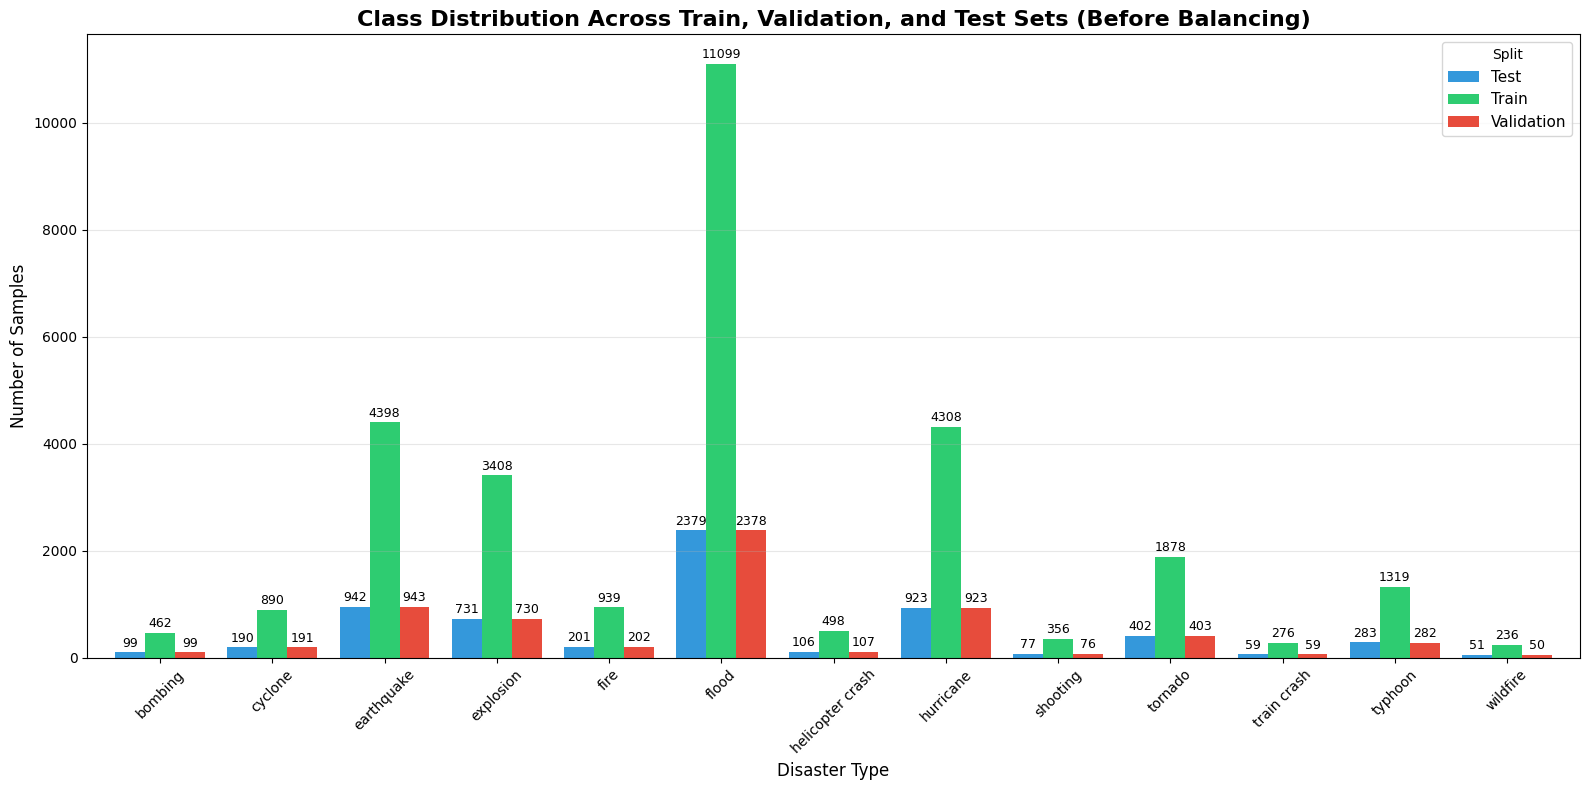

✅ Saved: class_distribution_before_balancing.png


In [5]:
# =========================
# 4. Class Distribution Visualization (Before Balancing)
# =========================
# Create DataFrame for visualization
split_data = pd.DataFrame({
    'class': np.concatenate([y_train, y_val, y_test]),
    'split': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test)
})

# Count per class and split
split_counts = split_data.groupby(['class', 'split']).size().unstack(fill_value=0)
split_counts.index = [class_names[i] for i in split_counts.index]

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
split_counts.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#e74c3c'], width=0.8)
ax.set_title('Class Distribution Across Train, Validation, and Test Sets (Before Balancing)', fontsize=16, fontweight='bold')
ax.set_xlabel('Disaster Type', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.legend(title='Split', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('class_distribution_before_balancing.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: class_distribution_before_balancing.png")

In [6]:
# =========================
# 5. Balance ONLY Training Data
# =========================
train_df = pd.DataFrame({'clean_tweet': X_train, 'label': y_train})
counts = Counter(train_df['label'])
max_count = max(counts.values())
min_count = min(counts.values())

print(f"Before balancing - Train: {dict(counts)}")

# Oversample minority classes
oversampled_list = []
for label in counts:
    df_label = train_df[train_df['label'] == label]
    if len(df_label) < max_count:
        df_label = resample(df_label, replace=True, n_samples=max_count, random_state=42)
    oversampled_list.append(df_label)
train_df_over = pd.concat(oversampled_list)

# Undersample all classes to midpoint
target_count = int((max_count + min_count) / 2)
final_balanced_list = []
for label in Counter(train_df_over['label']):
    df_label = train_df_over[train_df_over['label'] == label]
    if len(df_label) > target_count:
        df_label = resample(df_label, replace=False, n_samples=target_count, random_state=42)
    final_balanced_list.append(df_label)
train_df_balanced = pd.concat(final_balanced_list)

X_train_bal = train_df_balanced['clean_tweet']
y_train_bal = train_df_balanced['label']

print(f"After balancing - Train: {Counter(y_train_bal)}")

Before balancing - Train: {7: 4308, 5: 11099, 3: 3408, 2: 4398, 1: 890, 8: 356, 9: 1878, 4: 939, 11: 1319, 12: 236, 0: 462, 6: 498, 10: 276}
After balancing - Train: Counter({7: 5667, 5: 5667, 3: 5667, 2: 5667, 1: 5667, 8: 5667, 9: 5667, 4: 5667, 11: 5667, 12: 5667, 0: 5667, 6: 5667, 10: 5667})


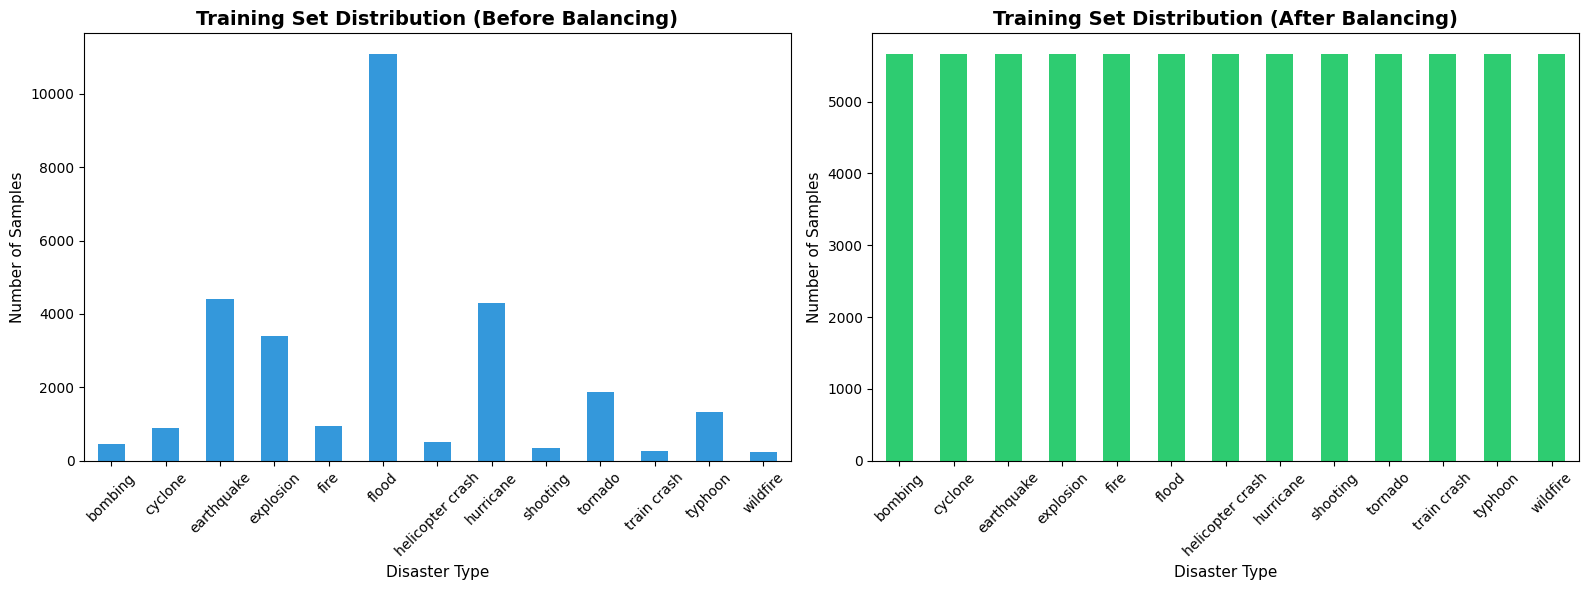

✅ Saved: class_distribution_balancing_comparison.png


In [7]:
# =========================
# 6. Class Distribution After Balancing (Visualization)
# =========================
# Show before vs after balancing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before balancing
before_counts = Counter(y_train)
before_df = pd.DataFrame({
    'Count': [before_counts[i] for i in range(len(class_names))]
}, index=class_names)

before_df.plot(kind='bar', ax=axes[0], color='#3498db', legend=False)
axes[0].set_title('Training Set Distribution (Before Balancing)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disaster Type', fontsize=11)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# After balancing
after_counts = Counter(y_train_bal)
after_df = pd.DataFrame({
    'Count': [after_counts[i] for i in range(len(class_names))]
}, index=class_names)

after_df.plot(kind='bar', ax=axes[1], color='#2ecc71', legend=False)
axes[1].set_title('Training Set Distribution (After Balancing)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Disaster Type', fontsize=11)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution_balancing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: class_distribution_balancing_comparison.png")

In [8]:
# =========================
# 7. Tokenization
# =========================
max_words = 15000
max_len = 120

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_bal)  # Fit ONLY on balanced training data

X_train_seq = tokenizer.texts_to_sequences(X_train_bal)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print(f"Train: {X_train_pad.shape}, Val: {X_val_pad.shape}, Test: {X_test_pad.shape}")

Train: (73671, 120), Val: (6443, 120), Test: (6443, 120)


In [9]:
# =========================
# 8. Enhanced Model Architecture
# =========================
def build_model():
    model = Sequential()

    model.add(Embedding(max_words, 128, input_length=max_len))
    model.add(Bidirectional(LSTM(128, return_sequences=True,
                                   dropout=0.3, recurrent_dropout=0.3,
                                   kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Bidirectional(LSTM(64, return_sequences=True,
                                   dropout=0.3, recurrent_dropout=0.3,
                                   kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(GlobalMaxPooling1D())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(len(class_names), activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

I0000 00:00:1787243805.659679      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787243805.665075      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# =========================
# 9. Train with VALIDATION Set
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    X_train_pad, y_train_bal,
    validation_data=(X_val_pad, y_val),  # ← Using VALIDATION set!
    epochs=30,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3498 - loss: 3.0322
Epoch 1: val_accuracy improved from None to 0.98557, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1535s 1s/step - accuracy: 0.6777 - loss: 1.8021 - val_accuracy: 0.9856 - val_loss: 0.5607 - learning_rate: 0.0010
Epoch 2/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9966 - loss: 0.4129
Epoch 2: val_accuracy improved from 0.98557 to 0.98588, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1487s 1s/step - accuracy: 0.9971 - loss: 0.3280 - val_accuracy: 0.9859 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 3/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9959 - loss: 0.1662
Epoch 3: val_accuracy improved from 0.98588 to 0.98650, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1331s 1s/step - accuracy: 0.9967 - loss: 0.1346 - val_accuracy: 0.9865 - val_loss: 0.1329 - learning_rate: 0.0010
Epoch 4/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9966 - loss: 0.0858
Epoch 4: val_accuracy improved from 0.98650 to 0.98945, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1393s 1s/step - accuracy: 0.9964 - loss: 0.0825 - val_accuracy: 0.9894 - val_loss: 0.1069 - learning_rate: 0.0010
Epoch 5/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9941 - loss: 0.1078
Epoch 5: val_accuracy improved from 0.98945 to 0.99022, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1353s 1s/step - accuracy: 0.9964 - loss: 0.0819 - val_accuracy: 0.9915 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 7/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9958 - loss: 0.0862
Epoch 7: val_accuracy did not improve from 0.99146
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1329s 1s/step - accuracy: 0.9965 - loss: 0.0823 - val_accuracy: 0.9913 - val_loss: 0.0890 - learning_rate: 0.0010
Epoch 8/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9964 - loss: 0.0760
Epoch 8: val_accuracy improved from 0.99146 to 0.99162, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1381s 1s/step - accuracy: 0.9962 - loss: 0.0812 - val_accuracy: 0.9916 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 9/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9948 - loss: 0.1148
Epoch 9: val_accuracy did not improve from 0.99162
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1408s 1s/step - accuracy: 0.9965 - loss: 0.0941 - val_accuracy: 0.9910 - val_loss: 0.0991 - learning_rate: 0.0010
Epoch 10/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9971 - loss: 0.0765
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: val_accuracy did not improve from 0.99162
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1375s 1s/step - accuracy: 0.9970 - loss: 0.0790 - val_accuracy: 0.9912 - val_loss: 0.1310 - learning_rate: 0.0010
Epoch 11/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9979 - loss: 0.0735
Epoch 11: val_accuracy improved from 0.99162 to 0.99224, saving model to


Epoch 11: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1376s 1s/step - accuracy: 0.9988 - loss: 0.0580 - val_accuracy: 0.9922 - val_loss: 0.0658 - learning_rate: 5.0000e-04
Epoch 12/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9961 - loss: 0.0634
Epoch 12: val_accuracy improved from 0.99224 to 0.99348, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1389s 1s/step - accuracy: 0.9981 - loss: 0.0520 - val_accuracy: 0.9935 - val_loss: 0.0629 - learning_rate: 5.0000e-04
Epoch 13/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9992 - loss: 0.0342
Epoch 13: val_accuracy did not improve from 0.99348
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1499s 1s/step - accuracy: 0.9989 - loss: 0.0334 - val_accuracy: 0.9924 - val_loss: 0.0619 - learning_rate: 5.0000e-04
Epoch 14/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9977 - loss: 0.0457
Epoch 14: val_accuracy did not improve from 0.99348
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1493s 1s/step - accuracy: 0.9988 - loss: 0.0375 - val_accuracy: 0.9919 - val_loss: 0.0576 - learning_rate: 5.0000e-04
Epoch 15/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9983 - loss: 0.0358
Epoch 15: val_accuracy did not improve from 0.99348
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1440s 1s/step - accuracy: 0.9986 - loss: 0.0349 - va


Epoch 27: finished saving model to best_model.h5
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1330s 1s/step - accuracy: 0.9998 - loss: 0.0104 - val_accuracy: 0.9936 - val_loss: 0.0357 - learning_rate: 1.2500e-04
Epoch 28/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9997 - loss: 0.0109
Epoch 28: val_accuracy did not improve from 0.99364
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1326s 1s/step - accuracy: 0.9998 - loss: 0.0098 - val_accuracy: 0.9929 - val_loss: 0.0377 - learning_rate: 1.2500e-04
Epoch 29/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9998 - loss: 0.0085
Epoch 29: val_accuracy did not improve from 0.99364
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 1342s 1s/step - accuracy: 0.9997 - loss: 0.0085 - val_accuracy: 0.9921 - val_loss: 0.0455 - learning_rate: 1.2500e-04
Epoch 30/30
1152/1152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9999 - loss: 0.0073
Epoch 30: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 30: val_accuracy did not improve from 0.99364
1152/1

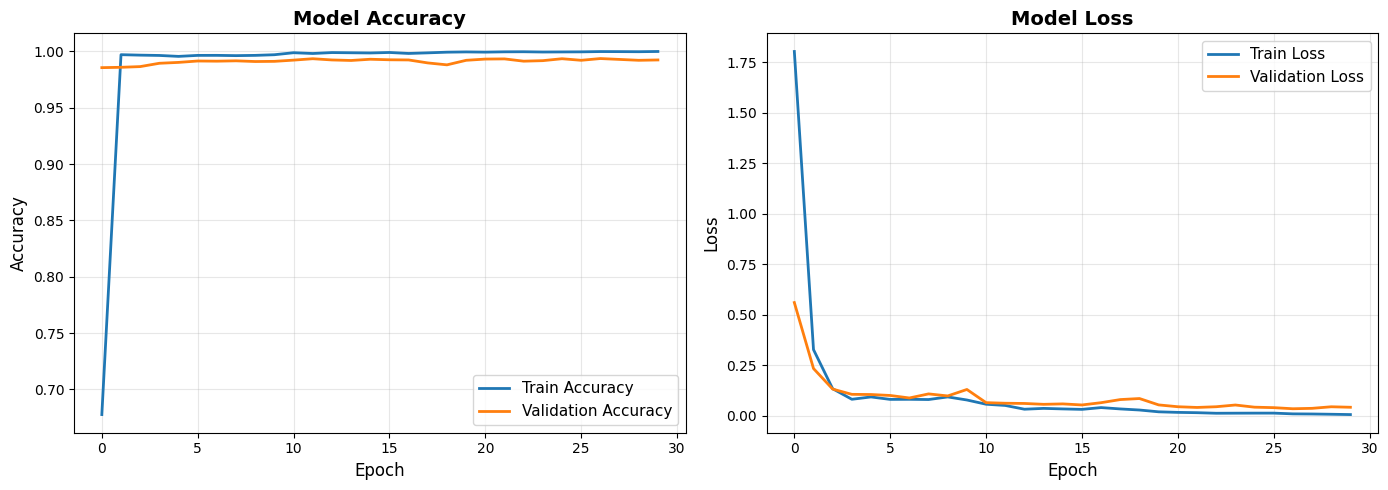

✅ Saved: training_history.png


In [11]:
# =========================
# 10. Training History Plots
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: training_history.png")

In [12]:
# =========================
# 11. FINAL EVALUATION on TEST Set (UNSEEN Data)
# =========================
from tensorflow.keras.models import load_model

# Load best model
best_model = load_model('best_model.h5')

# Final evaluation on test set
y_pred = best_model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "="*70)
print("📊 FINAL CLASSIFICATION REPORT (on UNSEEN test data)")
print("="*70)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Compare validation vs test accuracy
val_acc = max(history.history['val_accuracy'])
test_acc = np.mean(y_pred_classes == y_test)

print(f"\n📊 Accuracy Comparison:")
print(f"   Validation Accuracy (during training): {val_acc:.4f}")
print(f"   Test Accuracy (final evaluation):      {test_acc:.4f}")
print(f"   Gap: {val_acc - test_acc:.4f}")

if val_acc - test_acc > 0.02:
    print("   ⚠️ Overfitting detected! Consider more regularization.")
else:
    print("   ✅ Good generalization!")

202/202 ━━━━━━━━━━━━━━━━━━━━ 43s 205ms/step

📊 FINAL CLASSIFICATION REPORT (on UNSEEN test data)
                  precision    recall  f1-score   support

         bombing       0.98      0.94      0.96        99
         cyclone       0.97      1.00      0.99       190
      earthquake       0.99      0.99      0.99       942
       explosion       1.00      0.99      0.99       731
            fire       0.99      0.99      0.99       201
           flood       0.99      1.00      0.99      2379
helicopter crash       1.00      1.00      1.00       106
       hurricane       1.00      0.99      0.99       923
        shooting       0.99      1.00      0.99        77
         tornado       1.00      0.98      0.99       402
     train crash       1.00      1.00      1.00        59
         typhoon       1.00      0.98      0.99       283
        wildfire       1.00      1.00      1.00        51

        accuracy                           0.99      6443
       macro avg       0.99    

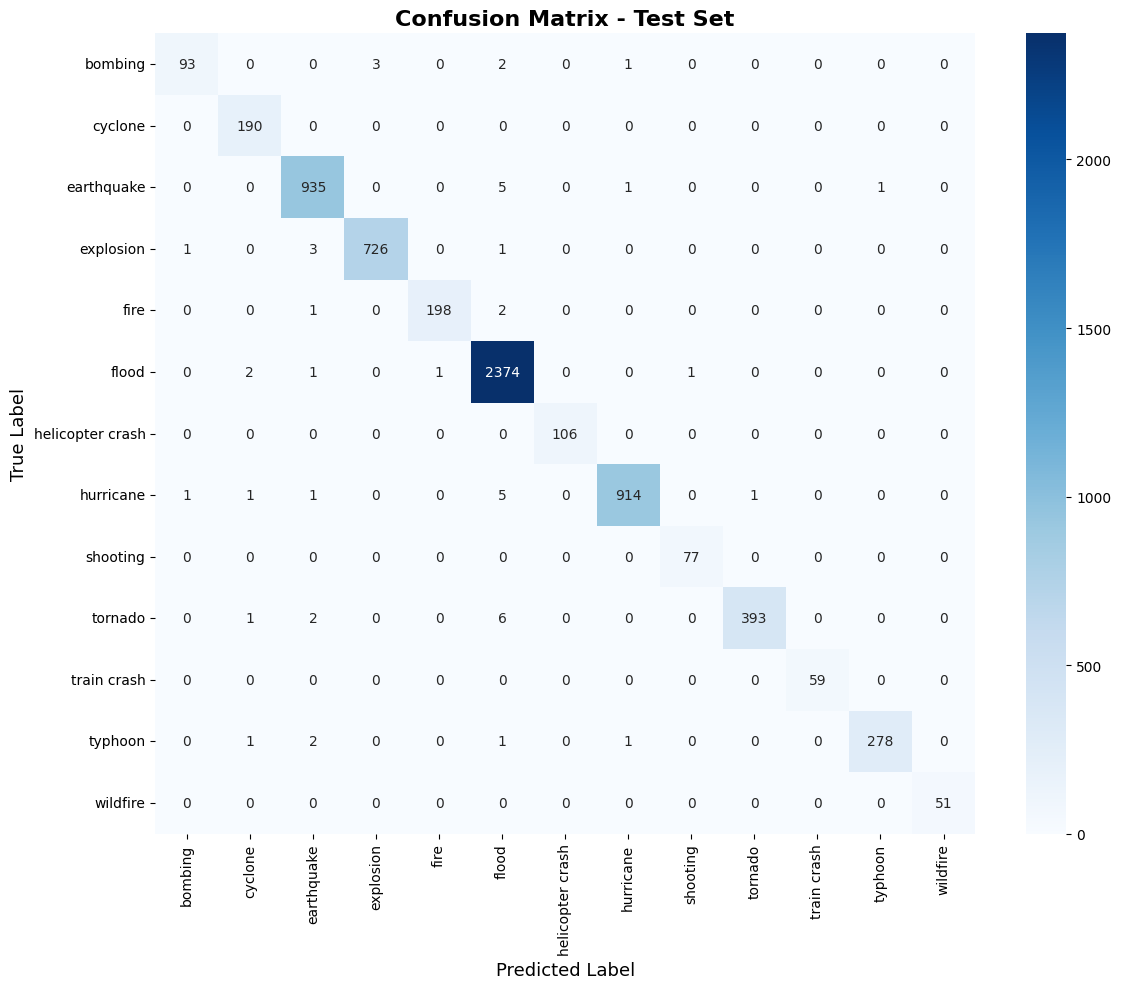

✅ Saved: confusion_matrix.png


In [13]:
# =========================
# 12. Confusion Matrix (High Resolution)
# =========================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'size': 10})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

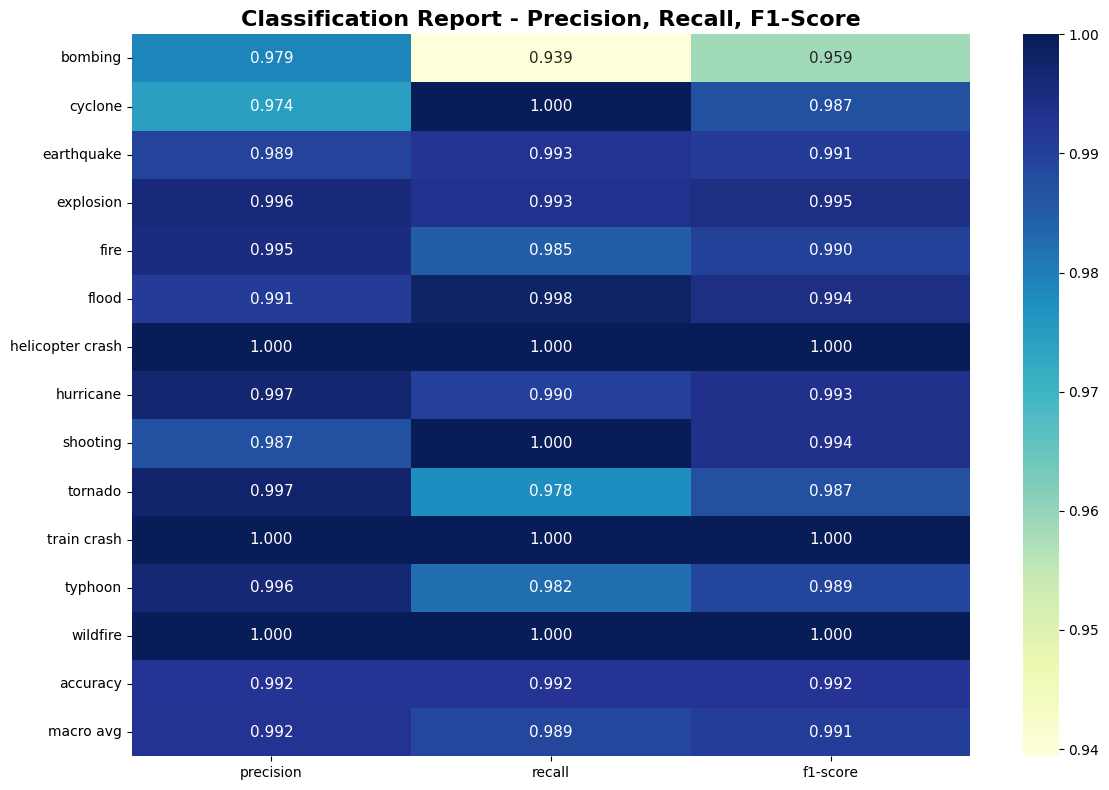

✅ Saved: classification_report_heatmap.png


In [14]:
# =========================
# 13. Classification Report Heatmap (High Resolution)
# =========================
report_dict = classification_report(
    y_test, y_pred_classes,
    target_names=class_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

# Select only precision, recall, f1-score
report_metrics = report_df.iloc[:-1, :3]

plt.figure(figsize=(12, 8))
sns.heatmap(report_metrics, annot=True, fmt='.3f', cmap='YlGnBu',
            annot_kws={'size': 11})
plt.title('Classification Report - Precision, Recall, F1-Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_report_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_report_heatmap.png")

In [15]:
# =========================
# 14. Prediction Helper Functions
# =========================
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    seq = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    return best_model.predict(padded, verbose=0)

def predict(texts):
    return np.argmax(predict_proba(texts), axis=1)

print("✅ Prediction functions ready!")

✅ Prediction functions ready!


In [16]:
# =========================
# 15. XAI: LIME Explanations
# =========================
print("\n" + "="*70)
print("🔍 LIME EXPLANATIONS")
print("="*70)

lime_explainer = LimeTextExplainer(class_names=class_names)

# Explain sample predictions
for idx in range(5):
    text = X_test.iloc[idx]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[y_pred_classes[idx]]

    print(f"\n🔹 Example {idx+1}: True={true_label}, Pred={pred_label}")
    print(f"   Text: {text[:150]}...")

    try:
        exp = lime_explainer.explain_instance(
            text,
            predict_proba,
            num_features=10,
            num_samples=500,
            top_labels=3
        )

        print("   📝 Top words:")
        for word, weight in exp.as_list(label=y_pred_classes[idx])[:8]:
            sign = "✅" if weight > 0 else "❌"
            print(f"      {sign} '{word}': {weight:.4f}")
    except Exception as e:
        print(f"   ⚠️ Error: {e}")

    print("-" * 50)


🔍 LIME EXPLANATIONS

🔹 Example 1: True=flood, Pred=flood
   Text: rt  many dead in nepal and india floods...
   📝 Top words:
      ✅ 'floods': 0.3020
      ✅ 'india': 0.1674
      ❌ 'nepal': -0.0555
      ✅ 'dead': 0.0424
      ✅ 'many': 0.0285
      ✅ 'in': 0.0205
      ✅ 'and': 0.0118
      ❌ 'rt': -0.0096
--------------------------------------------------

🔹 Example 2: True=flood, Pred=flood
   Text: rt   as a british citizen in canada i am horrified by lack of attention to floods in alberta  the us gets a...
   📝 Top words:
      ✅ 'floods': 0.1595
      ✅ 'alberta': 0.1527
      ✅ 'canada': 0.0559
      ❌ 'lack': -0.0438
      ✅ 'in': 0.0366
      ✅ 'citizen': 0.0316
      ✅ 'a': 0.0277
      ✅ 'am': 0.0202
--------------------------------------------------

🔹 Example 3: True=flood, Pred=flood
   Text: my thoughts are for the people who have been affected by flood water in queensland australia...
   📝 Top words:
      ✅ 'flood': 0.1184
      ✅ 'queensland': 0.1105
      ✅ 'austra


📊 Generating LIME Multi-Example Grid


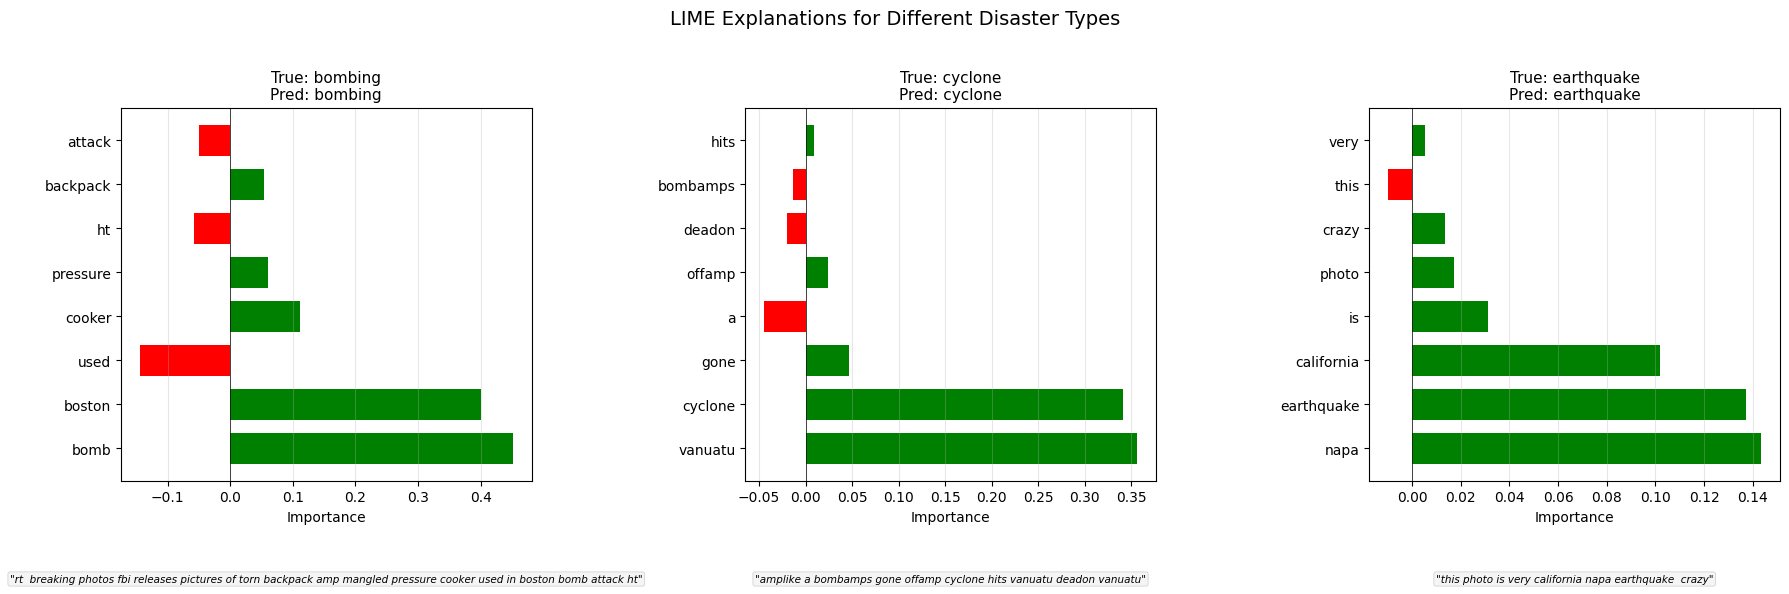

✅ Saved: lime_multi_examples.png


In [17]:
# =========================
# 16. XAI: LIME Multi-Example Grid
# =========================
print("\n📊 Generating LIME Multi-Example Grid")

# Select examples from different classes
example_indices = []
for class_idx in range(len(class_names)):
    indices = np.where(y_test == class_idx)[0]
    if len(indices) > 0:
        example_indices.append(indices[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, idx in enumerate(example_indices[:3]):
    text = X_test.iloc[idx]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[y_pred_classes[idx]]

    exp = lime_explainer.explain_instance(
        text,
        predict_proba,
        num_features=8,
        num_samples=300,
        top_labels=3
    )

    exp_list = exp.as_list(label=y_pred_classes[idx])
    words = [item[0] for item in exp_list[:8]]
    weights = [item[1] for item in exp_list[:8]]

    colors = ['green' if w > 0 else 'red' for w in weights]

    axes[i].barh(words, weights, color=colors, height=0.7)
    axes[i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[i].set_xlabel('Importance', fontsize=10)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='x')

    # Add tweet text
    display_text = text[:120] + "..." if len(text) > 120 else text
    axes[i].text(0.5, -0.25, f'"{display_text}"',
                transform=axes[i].transAxes,
                fontsize=7.5, ha='center', va='top', wrap=True,
                style='italic',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5',
                         edgecolor='#cccccc', linewidth=0.5))

plt.suptitle('LIME Explanations for Different Disaster Types', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lime_multi_examples.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: lime_multi_examples.png")

In [18]:
# =========================
# 17. Summary
# =========================
print("\n" + "="*70)
print("📋 MODEL PERFORMANCE SUMMARY")
print("="*70)

# Calculate per-class F1 scores
f1_scores = f1_score(y_test, y_pred_classes, average=None)

for i, class_name in enumerate(class_names):
    print(f"   {class_name}: F1 = {f1_scores[i]:.4f}")

print(f"\n   Macro F1: {np.mean(f1_scores):.4f}")
print(f"   Weighted F1: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}")

print("\n📁 Images saved:")
print("   - class_distribution_before_balancing.png")
print("   - class_distribution_balancing_comparison.png")
print("   - training_history.png")
print("   - confusion_matrix.png")
print("   - classification_report_heatmap.png")
print("   - lime_multi_examples.png")
print("="*70)


📋 MODEL PERFORMANCE SUMMARY
   bombing: F1 = 0.9588
   cyclone: F1 = 0.9870
   earthquake: F1 = 0.9910
   explosion: F1 = 0.9945
   fire: F1 = 0.9900
   flood: F1 = 0.9943
   helicopter crash: F1 = 1.0000
   hurricane: F1 = 0.9935
   shooting: F1 = 0.9935
   tornado: F1 = 0.9874
   train crash: F1 = 1.0000
   typhoon: F1 = 0.9893
   wildfire: F1 = 1.0000

   Macro F1: 0.9907
   Weighted F1: 0.9924

📁 Images saved:
   - class_distribution_before_balancing.png
   - class_distribution_balancing_comparison.png
   - training_history.png
   - confusion_matrix.png
   - classification_report_heatmap.png
   - lime_multi_examples.png
